# Music Genre Classification via Spotify Audio Features
## Capstone Project — Module 16: EDA & Baseline Model
**Author:** Brian Cabalic  
**Dataset:** Spotify Tracks Dataset
https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset

---

### Update
In my initial Module 16 assesment I was trying to decide between the **GTZAN dataset** or the **Spotify Dataset**.  I am choosing the Spotify dataset since the features (how the music is classified) are more sensible and relatable.

### Project Overview

In this notebook I will perform an Exploratory Data Analysis (EDA) and baseline machine learning pipeline for automatically classifying music into genres using Spotify's pre-computed audio features.

The research question guiding this work:

> *Can songs be automatically classified into musical genres based on extracted audio features such as danceability, energy, loudness, tempo, and acousticness — and which features carry the most discriminative signal?*

The Spotify dataset provides 13 numerical audio descriptors for 114,000 track-genre records spanning **114 genre labels**. Given the scale and genre overlap inherent in this dataset, this initial notebook documents the data cleaning, feature engineering, EDA visualization, and a K-Nearest Neighbors (KNN) baseline model. As mentioned in the rubric, I will prepare for the Module 24 comparision

### Notebook Sections
1. Import Libraries  
2. Load & Inspect the Dataset  
3. Data Cleaning  
4. Feature Engineering  
5. Exploratory Data Analysis  
6. Prepare Data for Modeling  
7. Baseline Model — KNN  
8. Summary of Findings & Next Steps  


## 1. Import Libraries

In [44]:
#Import Standard Librareis
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

#Scikit import
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, accuracy_score, f1_score
)

#Plot style
sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.figsize': (11, 5),
    'axes.spines.top': False,
    'axes.spines.right': False
})


## 2. Load & Inspect the Dataset

The Spotify Tracks dataset contains one row per (track, genre) pair.
A single track can appear in multiple genres — a key structural detail that
affects how we split data for modeling.


In [45]:
#Load Spotify Dataset
df = pd.read_csv('/content/spotify_dataset.csv', index_col=0)

print(f"Shape:   {df.shape}")
print(f"Columns: {list(df.columns)}")
print()
df.head(10)


Shape:   (114000, 20)
Columns: ['track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']



,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
5,01MVOl9KtVTNfFiBU9I7dc,Tyrone Wells,Days I Will Remember,Days I Will Remember,58,214240,False,0.688,0.4810,6,-8.807,1,0.1050,0.2890,0.000000,0.1890,0.6660,98.017,4,acoustic
6,6Vc5wAMmXdKIAM7WUoEb7N,A Great Big World;Christina Aguilera,Is There Anybody Out There?,Say Something,74,229400,False,0.407,0.1470,2,-8.822,1,0.0355,0.8570,0.000003,0.0913,0.0765,141.284,3,acoustic
7,1EzrEOXmMH3G43AXT1y7pA,Jason Mraz,We Sing. We Dance. We Steal Things.,I'm Yours,80,242946,False,0.703,0.4440,11,-9.331,1,0.0417,0.5590,0.000000,0.0973,0.7120,150.960,4,acoustic
8,0IktbUcnAGrvD03AWnz3Q8,Jason Mraz;Colbie Caillat,We Sing. We Dance. We Steal Things.,Lucky,74,189613,False,0.625,0.4140,0,-8.700,1,0.0369,0.2940,0.000000,0.1510,0.6690,130.088,4,acoustic
9,7k9GuJYLp2AzqokyEdwEw2,Ross Copperman,Hunger,Hunger,56,205594,False,0.442,0.6320,1,-6.770,1,0.0295,0.4260,0.004190,0.0735,0.1960,78.899,4,acoustic


You can see here I will be most interested in features like danceability, energy, loudness, speechines, acousticness, instrumentalness and liveness to name a few.

In [46]:
#Let's look at the data characteristics
print("=== Data Types ===")
print(df.dtypes)
print()
print(f"Unique genres   : {df['track_genre'].nunique()}")
print(f"Unique track IDs: {df['track_id'].nunique()}")
print(f"Total rows      : {len(df)}")
print()
print("=== Genre Count (first 25 alphabetically) ===")
print(df['track_genre'].value_counts().sort_index().head(25))


=== Data Types ===
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

Unique genres   : 114
Unique track IDs: 89741
Total rows      : 114000

=== Genre Count (first 25 alphabetically) ===
track_genre
acoustic          1000
afrobeat          1000
alt-rock          1000
alternative       1000
ambient           1000
anime             1000
black-metal       1000
bluegrass         1000
blues             1000
brazil            1000
breakbeat         1000
british           1000


This dataset has an extremely broad genre count! 114 Genres tells me there will be some overlap. This is one of the reasons why I choose this over the GTZAN dataset.  Now I need to take the numerical columns (float64, int64) and remove the text based features since data like artist, track_name, album_name - won't be relevant. There is no benefit transforming these to numerical value.

Rounding to 3 decimal places for now, this should be sufficient.

In [47]:
# Statistical summary
# Identify numeric feature columns (exclude metadata)
NUMERIC_FEATS = [
    'popularity', 'duration_ms', 'danceability', 'energy', 'key',
    'loudness', 'mode', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature'
]
df[NUMERIC_FEATS].describe().T.round(3)


,count,mean,std,min,25%,50%,75%,max
popularity,114000.0,33.239,22.305,0.000,17.000,35.000,50.000,100.000
duration_ms,114000.0,228029.153,107297.713,0.000,174066.000,212906.000,261506.000,5237295.000
danceability,114000.0,0.567,0.174,0.000,0.456,0.580,0.695,0.985
energy,114000.0,0.641,0.252,0.000,0.472,0.685,0.854,1.000
key,114000.0,5.309,3.560,0.000,2.000,5.000,8.000,11.000
loudness,114000.0,-8.259,5.029,-49.531,-10.013,-7.004,-5.003,4.532
mode,114000.0,0.638,0.481,0.000,0.000,1.000,1.000,1.000
speechiness,114000.0,0.085,0.106,0.000,0.036,0.049,0.084,0.965
acousticness,114000.0,0.315,0.333,0.000,0.017,0.169,0.598,0.996
instrumentalness,114000.0,0.156,0.310,0.000,0.000,0.000,0.049,1.000


## 3. Data Cleaning

This is a markdown checklist for data cleaning steps to perform before modeling. It covers the essentials: finding and handling missing values, dealing with duplicate track IDs (and understanding whether they're errors or intentional), and dropping columns that won't help my model. I will also make sure numeric columns are stored as the right data types and flag outliers.

### Checks performed
- **Missing / null values** — identify and handle
- **Duplicate track_ids** — understand whether duplicates are data errors or
  intentional multi-genre assignments
- **Non-informative columns** — drop metadata not useful for modeling
- **Data type casting** — ensure numeric features are correctly typed
- **Outlier inspection** — flag implausible values


In [48]:
#Check Missing values
missing = df.isnull().sum()
print("Columns with missing values:")
missing_cols = missing[missing > 0]
if len(missing_cols) == 0:
    print("  None — dataset is complete.")
else:
    print(missing_cols)

#Check Duplicate track_ids
dup_track_count = df['track_id'].duplicated().sum()
tracks_in_multi_genre = (
    df.groupby('track_id')['track_genre'].nunique()
    .pipe(lambda s: (s > 1).sum())
)
print(f"\nDuplicate track_id rows : {dup_track_count:,}")
print(f"Tracks in >1 genre      : {tracks_in_multi_genre:,}")
print()


Columns with missing values:
artists       1
album_name    1
track_name    1
dtype: int64

Duplicate track_id rows : 24,259
Tracks in >1 genre      : 16,299



NOTICE there are over 24,000 duplicate track IDs.  This is no mistake. They exist because **Spotify intentionally places the same song into multiple genre playlists**. 16,299 unique tracks appear in more than one genre, meaning the duplicates are almost entirely explained by multi-genre assignments. For my modeling purposes, each row represents a distinct and valid (song, genre) pairing.

Another way to put it - each row is essentially asking "How does this song perform in this genre?" -  So I will NOT drop this data.



In [49]:
#Drop non-informative columns
# track_id  → identifier only
# artists   → text; would need NLP encoding (out of scope for this EDA)
# album_name, track_name → same reason
COLS_TO_DROP = ['track_id', 'artists', 'album_name', 'track_name']
df_clean = df.drop(columns=COLS_TO_DROP).copy()

#Cast explicit to binary integer
df_clean['explicit'] = df_clean['explicit'].map({'True': 1, 'False': 0}).fillna(0).astype(int)

#Verify numeric types
for col in NUMERIC_FEATS:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

leftover_nulls = df_clean.isnull().sum().sum()
print(f"Nulls after cleaning: {leftover_nulls}")
print(f"Cleaned dataset shape: {df_clean.shape}")
print(f"\nFeature columns kept:")
print([c for c in df_clean.columns if c != 'track_genre'])


Nulls after cleaning: 0
Cleaned dataset shape: (114000, 16)

Feature columns kept:
['popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']


1.  I drop columns that won't help my model.  Model wont learn anything meaningful like a track_name.  Model needs actual numeric signals like tempo and energy instead.

2.  Convert "explicit" column from text to numbers — right now it says "True" or "False" for 1 and 0. Keeping "explicit" feature for any business purposes where playing explicit content is NOT allowed.

3. Double-check all numeric columns are actually stored as numbers.  Forces everything into the right numnerical format

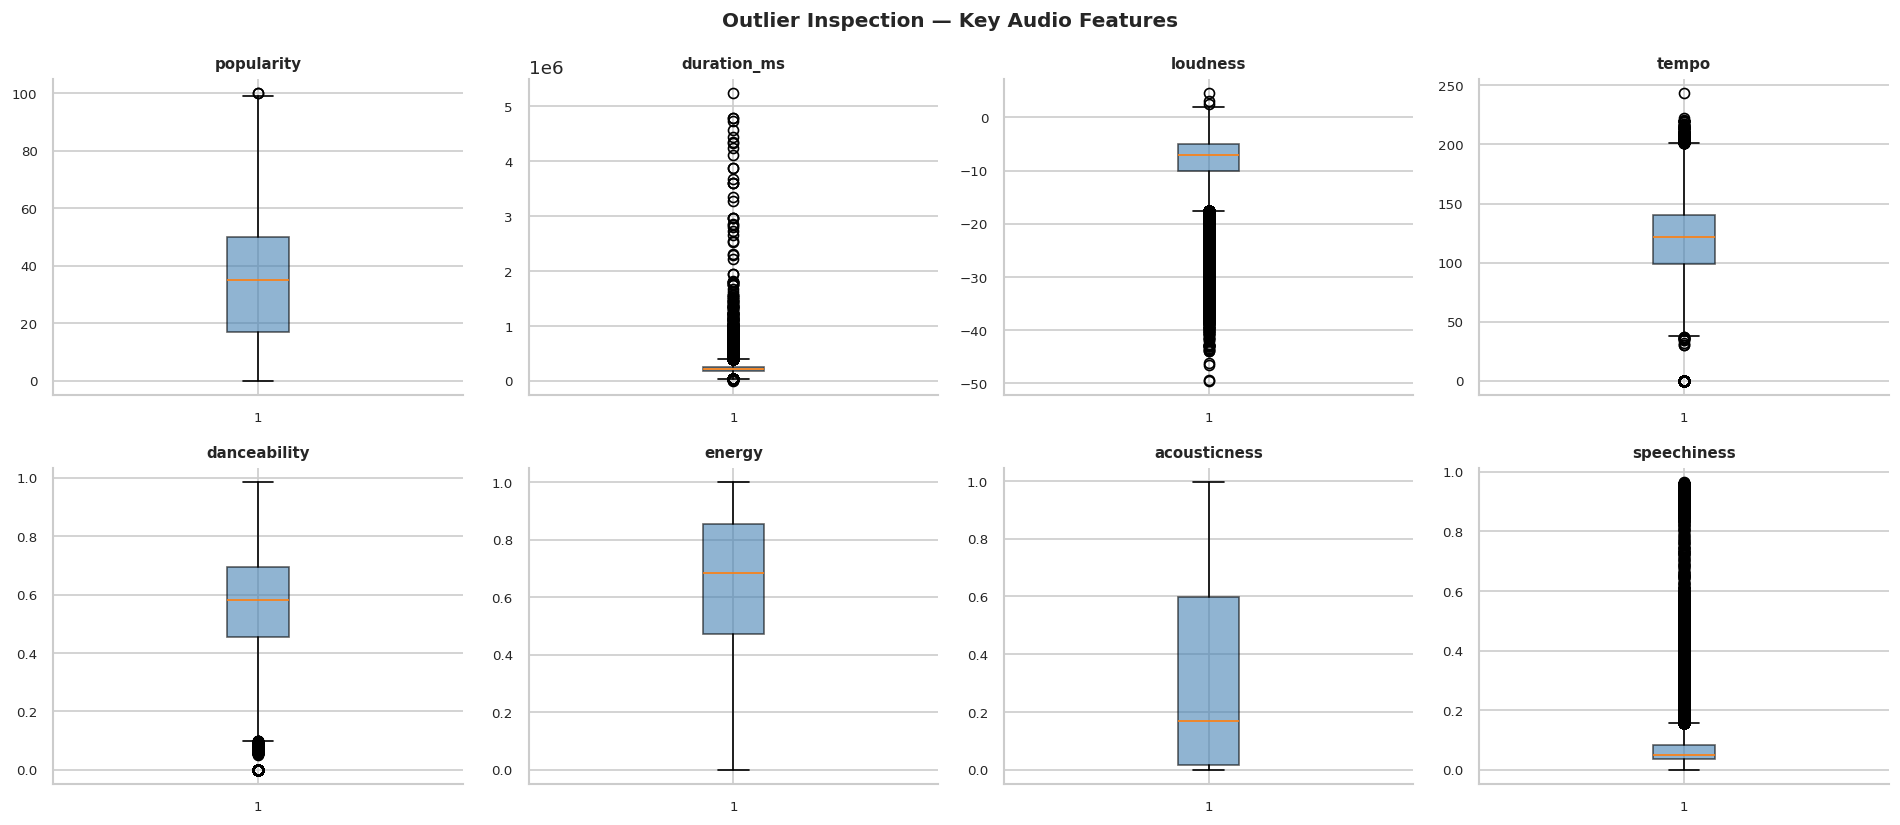

Tracks above 99th percentile duration (8.8 min): 1,140
These are retained — long tracks are legitimate (live recordings, classical, ambient).


In [28]:
#Outlier inspection for key audio features
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

outlier_feats = [
    'popularity', 'duration_ms', 'loudness', 'tempo',
    'danceability', 'energy', 'acousticness', 'speechiness'
]

for i, feat in enumerate(outlier_feats):
    axes[i].boxplot(df_clean[feat].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(feat, fontsize=9, fontweight='bold')
    axes[i].tick_params(labelsize=8)

plt.suptitle("Outlier Inspection — Key Audio Features", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_outlier_boxplots.png', dpi=120, bbox_inches='tight')
plt.show()

# Flag extreme duration values
p99_dur = df_clean['duration_ms'].quantile(0.99)
long_tracks = (df_clean['duration_ms'] > p99_dur).sum()
print(f"Tracks above 99th percentile duration ({p99_dur/60000:.1f} min): {long_tracks:,}")
print("These are retained — long tracks are legitimate (live recordings, classical, ambient).")


The box plots are the main tool here. For each feature, a box plot shows the "normal range" of values. Any dots or lines that appear far above or below the box are outliers - songs unusually high or low compared to the rest of the data.

The tricky part here is the duration check.  I find the cutoff point where only the top 1% longest songs live, count how many songs are above that line, and then makes a judgment call — those super-long tracks are kept because they have a legitimate explanation (live recordings, classical pieces, ambient music genuinely run long).

This is a good example of where an outlier isn't automatically always an error.

Another interesting example is the Speeciness. Speechiness measures how much of a track is spoken word, so the vast majority of songs score very low (close to 0). The result is a heavily skewed distribution where "outliers" on the high end aren't really errors, they're just speech-heavy (podcasts, comedy tracks etc). I will keep these rather than remove them.


## 4. Feature Engineering

Spotify's built-in audio features are solid on their own, but I'm going to create a few new custom features by combining existing ones — the idea being that the relationship between features (not just the features themselves) might do a better job of distinguishing one genre from another.

| New Feature | Formula | Rationale |
|---|---|---|
| `energy_valence_ratio` | `energy / (valence + 0.01)` | Separates high-energy dark music (metal) from high-energy happy music (pop/dance) |
| `acoustic_energy_diff` | `acousticness - energy` | Classical / folk vs electronic — strong polarity |
| `dance_tempo_product` | `danceability × tempo` | Captures uptempo groove (disco, dancehall) vs slow dance (ballads) |
| `speech_instrumental_diff` | `speechiness - instrumentalness` | Separates hip-hop / podcast from ambient / classical |
| `duration_min` | `duration_ms / 60000` | Human-readable; improves model interpretability |
| `loudness_norm` | `(loudness + 60) / 60` | Re-scales loudness from ~[-60, 0] dB to [0, 1] |


In [50]:
#Composite feature engineering
df_clean['energy_valence_ratio']     = df_clean['energy'] / (df_clean['valence'] + 0.01)
df_clean['acoustic_energy_diff']     = df_clean['acousticness'] - df_clean['energy']
df_clean['dance_tempo_product']      = df_clean['danceability'] * df_clean['tempo']
df_clean['speech_instrumental_diff'] = df_clean['speechiness'] - df_clean['instrumentalness']
df_clean['duration_min']             = df_clean['duration_ms'] / 60000.0
df_clean['loudness_norm']            = (df_clean['loudness'] + 60) / 60.0

ENGINEERED = [
    'energy_valence_ratio', 'acoustic_energy_diff',
    'dance_tempo_product', 'speech_instrumental_diff',
    'duration_min', 'loudness_norm'
]

print("Engineered features added:", ENGINEERED)
print(f"\nTotal features for modeling: {df_clean.shape[1] - 1}  (excl. track_genre)")
df_clean[ENGINEERED].describe().T.round(4)


Engineered features added: ['energy_valence_ratio', 'acoustic_energy_diff', 'dance_tempo_product', 'speech_instrumental_diff', 'duration_min', 'loudness_norm']

Total features for modeling: 21  (excl. track_genre)


,count,mean,std,min,25%,50%,75%,max
energy_valence_ratio,114000.0,2.2085,4.2880,0.0000,0.9001,1.2820,2.1106,99.9001
acoustic_energy_diff,114000.0,-0.3265,0.5446,-0.9994,-0.7800,-0.4860,0.0480,0.9959
dance_tempo_product,114000.0,68.9709,25.0327,0.0000,51.8741,69.9004,85.9789,167.7723
speech_instrumental_diff,114000.0,-0.0714,0.3360,-1.0000,0.0083,0.0377,0.0689,0.9650
duration_min,114000.0,3.8005,1.7883,0.0000,2.9011,3.5484,4.3584,87.2882
loudness_norm,114000.0,0.8624,0.0838,0.1745,0.8331,0.8833,0.9166,1.0755


The goal was to think about how a human actually describes different genres, and then translate that into math.

For example, metal and pop can both be high-energy, but metal feels dark and tense while pop feels bright and happy — so dividing energy by valence creates a single number that attempts to capture that contrast. Similarly, the difference between acousticness and energy neatly separates a classical guitar recording from an EDM drop, because those two features naturally pull in opposite directions depending on the genre.

The speech vs. instrumental difference was a direct response to the speechiness outlier discussion — hip-hop and podcasts live at one extreme, ambient and classical at the other, and that gap is worth encoding explicitly.

The last two are more about housekeeping: converting milliseconds to minutes makes the feature readable, and rescaling loudness to a 0–1 range puts it on the same playing field as every other feature so the model doesn't over-weight it just because its raw numbers happen to be larger.

## 5. Exploratory Data Analysis (EDA)

### 5.1 Genre Class Distribution


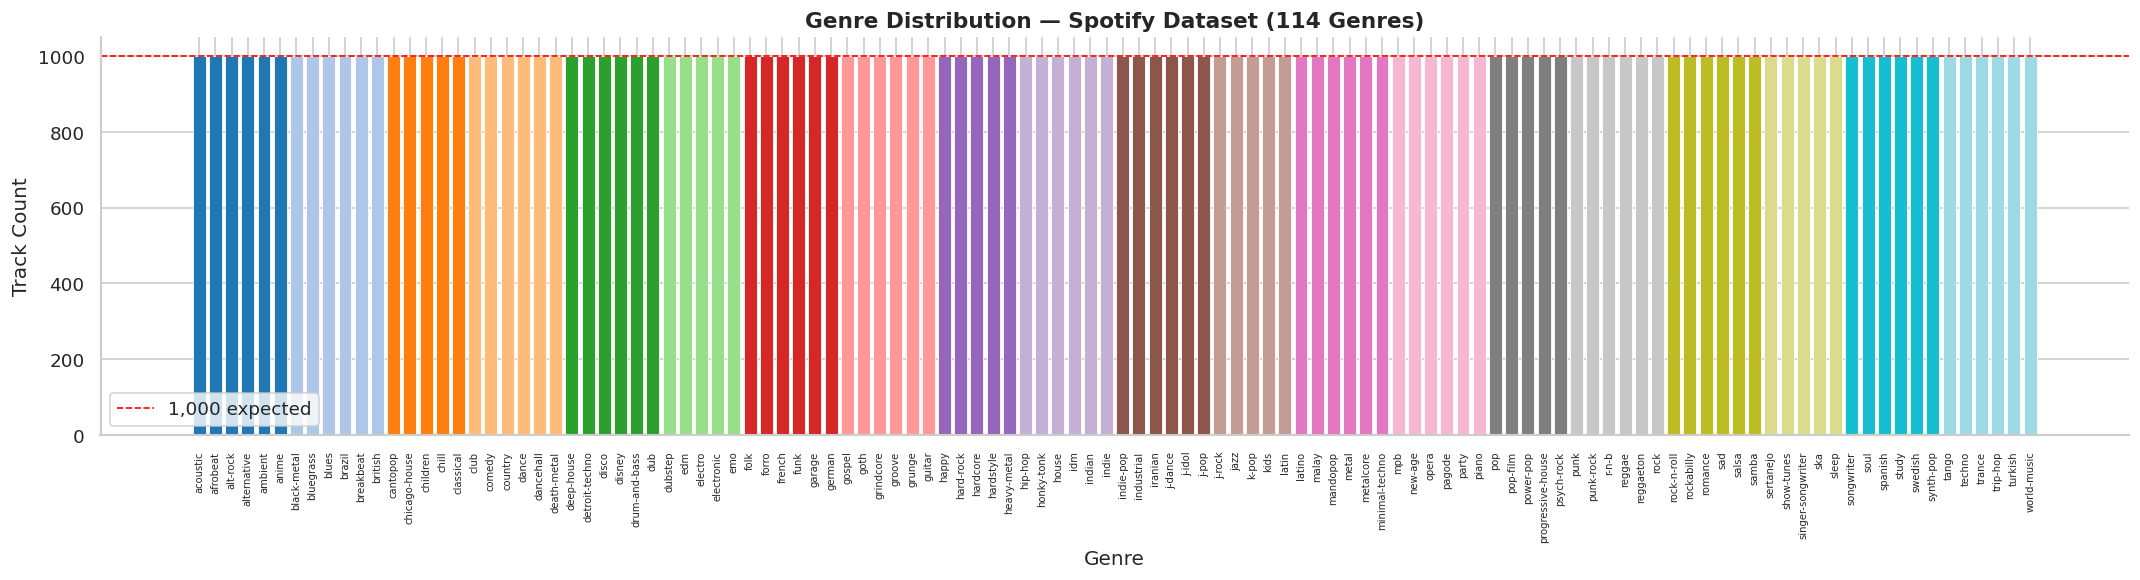

All genres have exactly 1,000 tracks — perfectly balanced dataset.
Random-chance baseline accuracy: 0.88%


In [51]:
# All 114 genres — perfectly balanced (1,000 tracks each)
genre_counts = df_clean['track_genre'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(18, 5))
colors = plt.cm.tab20(np.linspace(0, 1, len(genre_counts)))
ax.bar(genre_counts.index, genre_counts.values, color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(1000, color='red', linestyle='--', linewidth=1, label='1,000 expected')
ax.set_title("Genre Distribution — Spotify Dataset (114 Genres)", fontsize=13, fontweight='bold')
ax.set_xlabel("Genre")
ax.set_ylabel("Track Count")
ax.tick_params(axis='x', rotation=90, labelsize=6)
ax.legend()
plt.tight_layout()
plt.savefig('fig_genre_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"All genres have exactly 1,000 tracks — perfectly balanced dataset.")
print(f"Random-chance baseline accuracy: {1/114:.2%}")


The Spoitify dataset has 114 genres and 1,000 tracks each. Ideal!  No class weighting is needed, and the 0.88% random-chance baseline gives a clean benchmark to measure every future model against.

### 5.2 Audio Feature Distributions (Global)

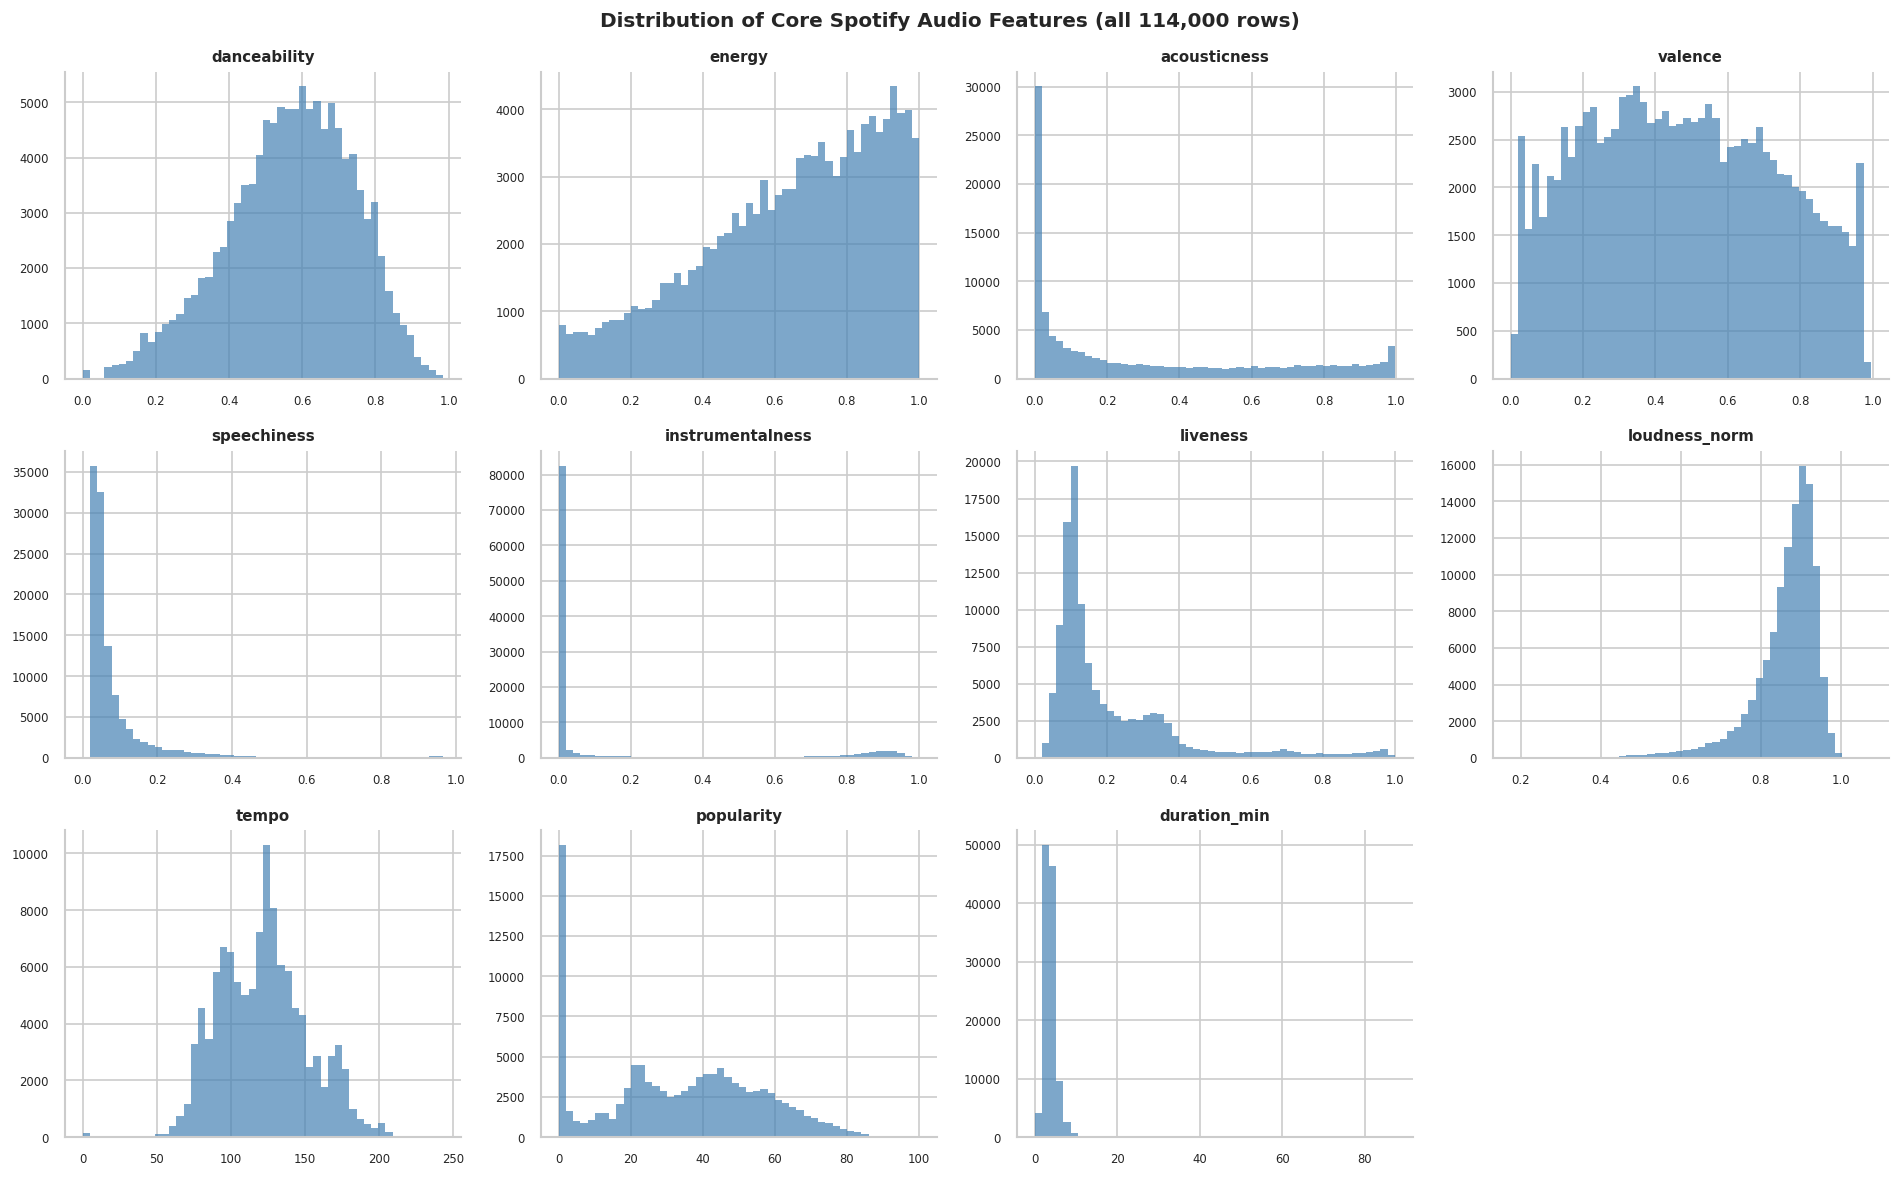

In [31]:
#Overall distribution of each core Spotify audio feature
core_plot_feats = [
    'danceability', 'energy', 'acousticness', 'valence',
    'speechiness', 'instrumentalness', 'liveness', 'loudness_norm',
    'tempo', 'popularity', 'duration_min'
]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(core_plot_feats):
    axes[i].hist(df_clean[feat].dropna(), bins=50, color='steelblue', alpha=0.7, edgecolor='none')
    axes[i].set_title(feat, fontsize=9, fontweight='bold')
    axes[i].tick_params(labelsize=7)
    axes[i].set_ylabel('')

# Hide unused subplot
for j in range(len(core_plot_feats), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution of Core Spotify Audio Features (all 114,000 rows)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_feature_histograms.png', dpi=120, bbox_inches='tight')
plt.show()


This reveals how the data is distributed and skewed.  I can use this information to visualize how some features may behave differently during modeling.

### 5.3 Key Feature Distributions Across a Representative Genre Sample

With 114 genres, plotting all simultaneously is impractical.
I will select **15 representative genres** spanning acoustic, electronic,
metal, classical, hip-hop, and regional styles for visual comparison.


Subset shape: (15000, 22)


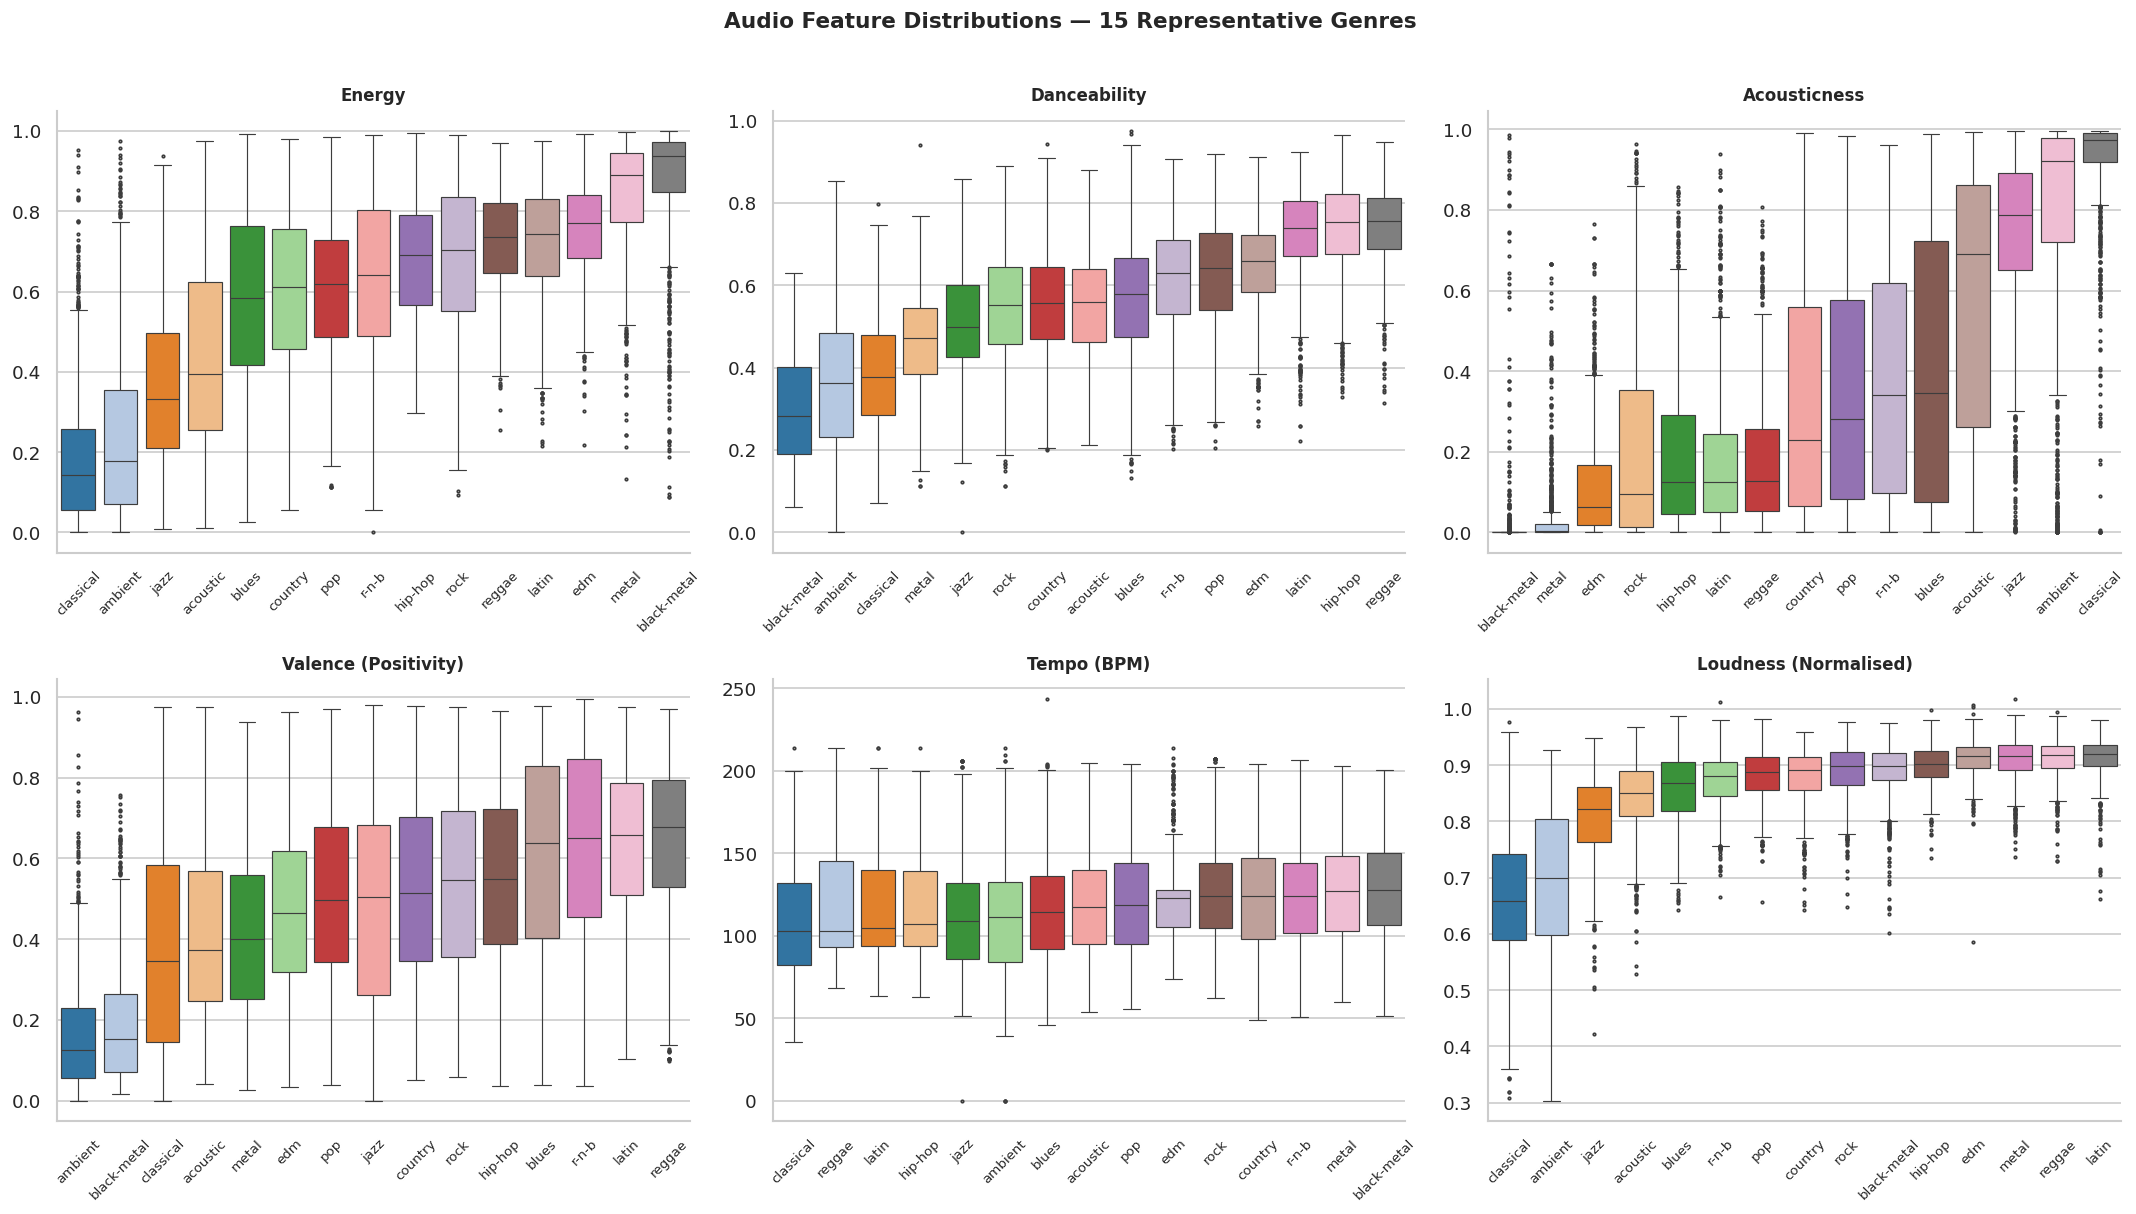

In [52]:
#Select 15 representative genres
REPRESENTATIVE = [
    'classical', 'jazz', 'blues', 'hip-hop', 'metal', 'black-metal',
    'pop', 'edm', 'ambient', 'reggae', 'latin', 'country',
    'rock', 'r-n-b', 'acoustic'
]

df_rep = df_clean[df_clean['track_genre'].isin(REPRESENTATIVE)].copy()
print(f"Subset shape: {df_rep.shape}")

key_features_plot = [
    ('energy',        'Energy'),
    ('danceability',  'Danceability'),
    ('acousticness',  'Acousticness'),
    ('valence',       'Valence (Positivity)'),
    ('tempo',         'Tempo (BPM)'),
    ('loudness_norm', 'Loudness (Normalised)'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
palette_15 = sns.color_palette("tab20", n_colors=15)

for i, (feat, label) in enumerate(key_features_plot):
    order = (df_rep.groupby('track_genre')[feat]
             .median().reindex(REPRESENTATIVE).sort_values().index)
    sns.boxplot(data=df_rep, x='track_genre', y=feat, order=order,
                palette=palette_15, ax=axes[i], linewidth=0.7, fliersize=1.5)
    axes[i].set_title(label, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].tick_params(axis='x', rotation=45, labelsize=8)

plt.suptitle("Audio Feature Distributions — 15 Representative Genres",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_feature_boxplots_rep.png', dpi=120, bbox_inches='tight')
plt.show()


This lets me visually compare how each genre sits relative to the others on a given feature, so you can immediately spot things like classical and acoustic anchoring the low end of energy while metal and black-metal dominate the high end, or how ambient and classical sit at opposite extremes from hip-hop and r&b on acousticness.

### 5.4 Feature Correlation Matrix

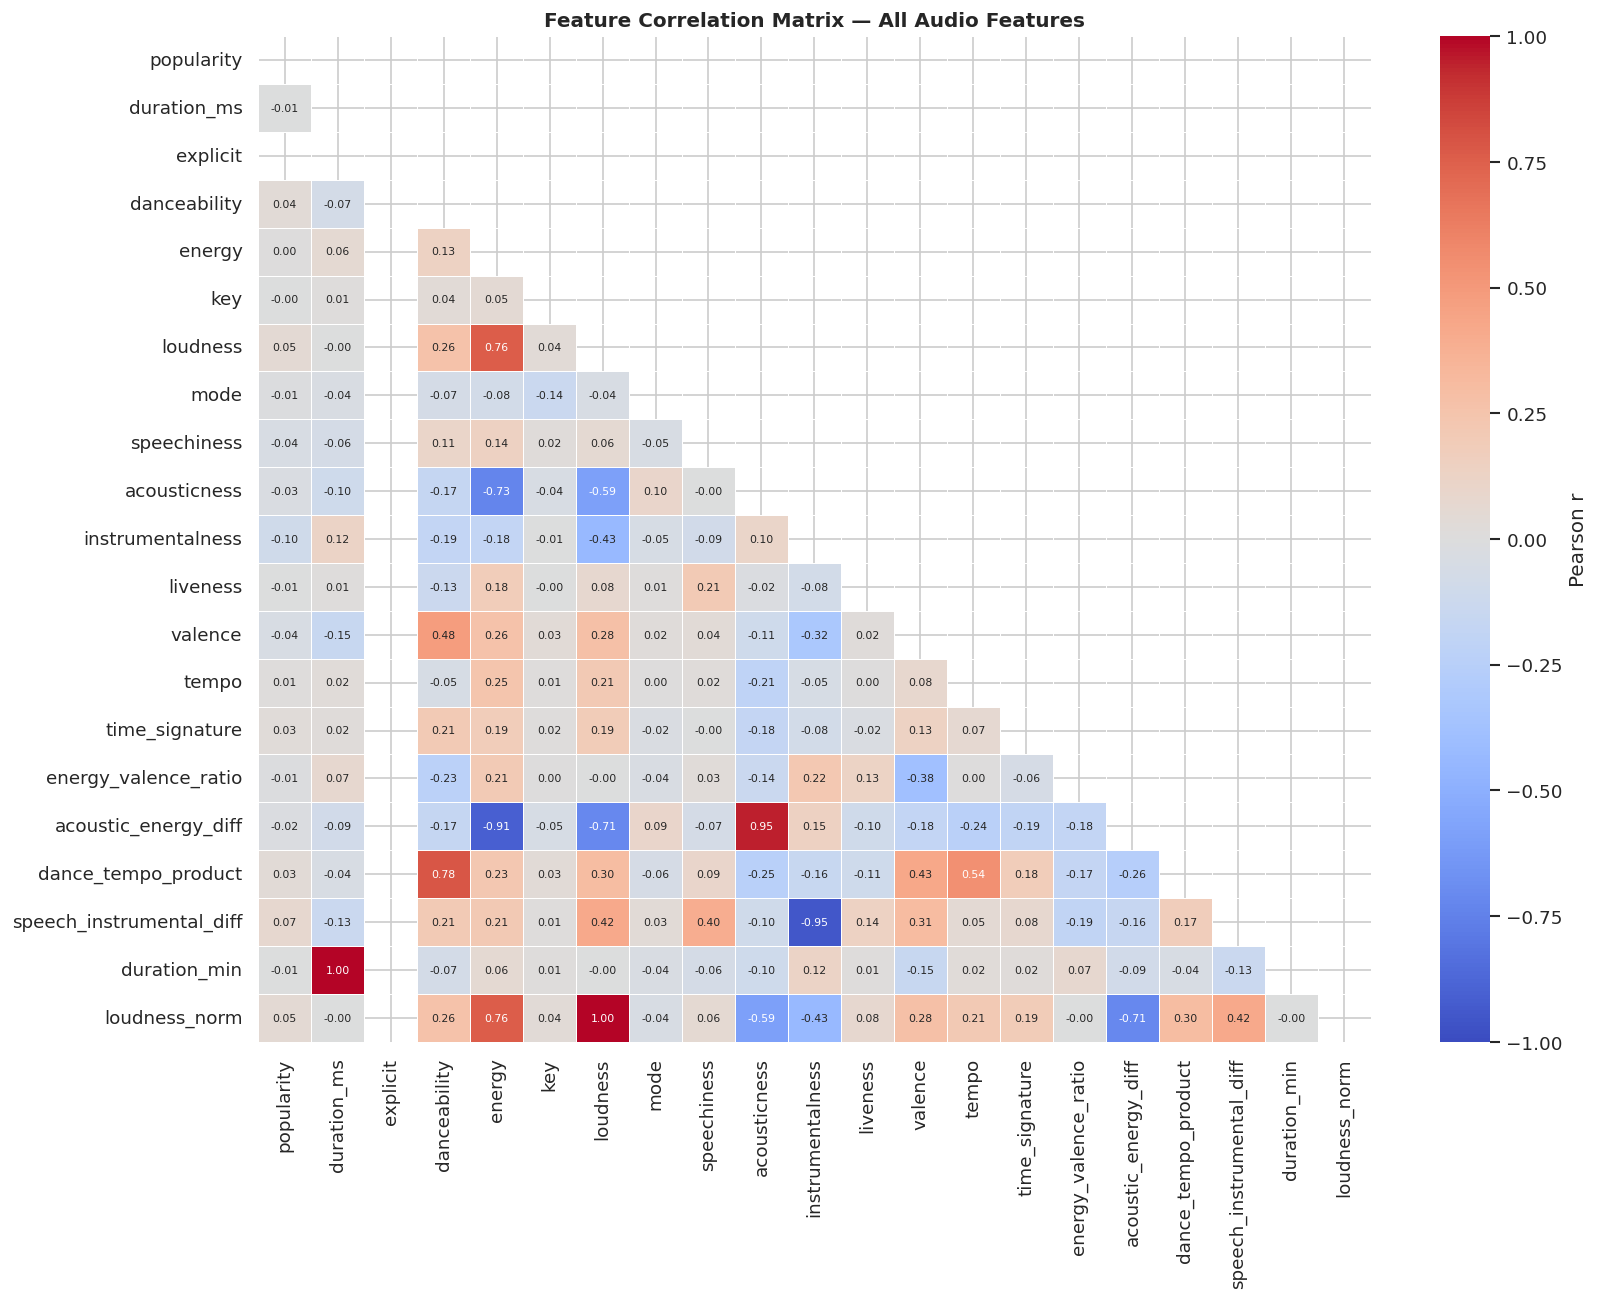

Strongest feature correlations (|r| > 0.5):
                  feat_a               feat_b         r
            duration_min          duration_ms  1.000000
           loudness_norm             loudness  1.000000
speech_instrumental_diff     instrumentalness -0.949605
    acoustic_energy_diff         acousticness  0.949519
    acoustic_energy_diff               energy -0.909946
     dance_tempo_product         danceability  0.782159
                loudness               energy  0.761690
           loudness_norm               energy  0.761690
            acousticness               energy -0.733906
           loudness_norm acoustic_energy_diff -0.711898
    acoustic_energy_diff             loudness -0.711898
            acousticness             loudness -0.589803


In [53]:
#Correlation among all numeric + engineered features
all_feat_cols = [c for c in df_clean.columns if c != 'track_genre']
corr = df_clean[all_feat_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, cmap='coolwarm', vmin=-1, vmax=1, center=0,
    annot=True, fmt='.2f', annot_kws={'size': 6.5},
    linewidths=0.3, linecolor='white', ax=ax,
    cbar_kws={'label': 'Pearson r'}
)
ax.set_title("Feature Correlation Matrix — All Audio Features",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_correlation_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

# Print strongest correlations
corr_pairs = (corr.where(mask == False)
              .stack()
              .reset_index()
              .rename(columns={'level_0':'feat_a','level_1':'feat_b',0:'r'})
              .assign(abs_r=lambda x: x['r'].abs())
              .sort_values('abs_r', ascending=False)
              .query("feat_a != feat_b"))

print("Strongest feature correlations (|r| > 0.5):")
print(corr_pairs[corr_pairs['abs_r'] > 0.5][['feat_a','feat_b','r']].head(12).to_string(index=False))


Here we see  the heatmap shows how strongly every numeric and engineered feature relates to every other one, with blue indicating negative relationships, red indicating positive ones. The printed table below shows only the pairs with a correlation above 0.5 worth paying attention to.

### 5.5 Feature Discriminability — Between-Genre Variance Ratio

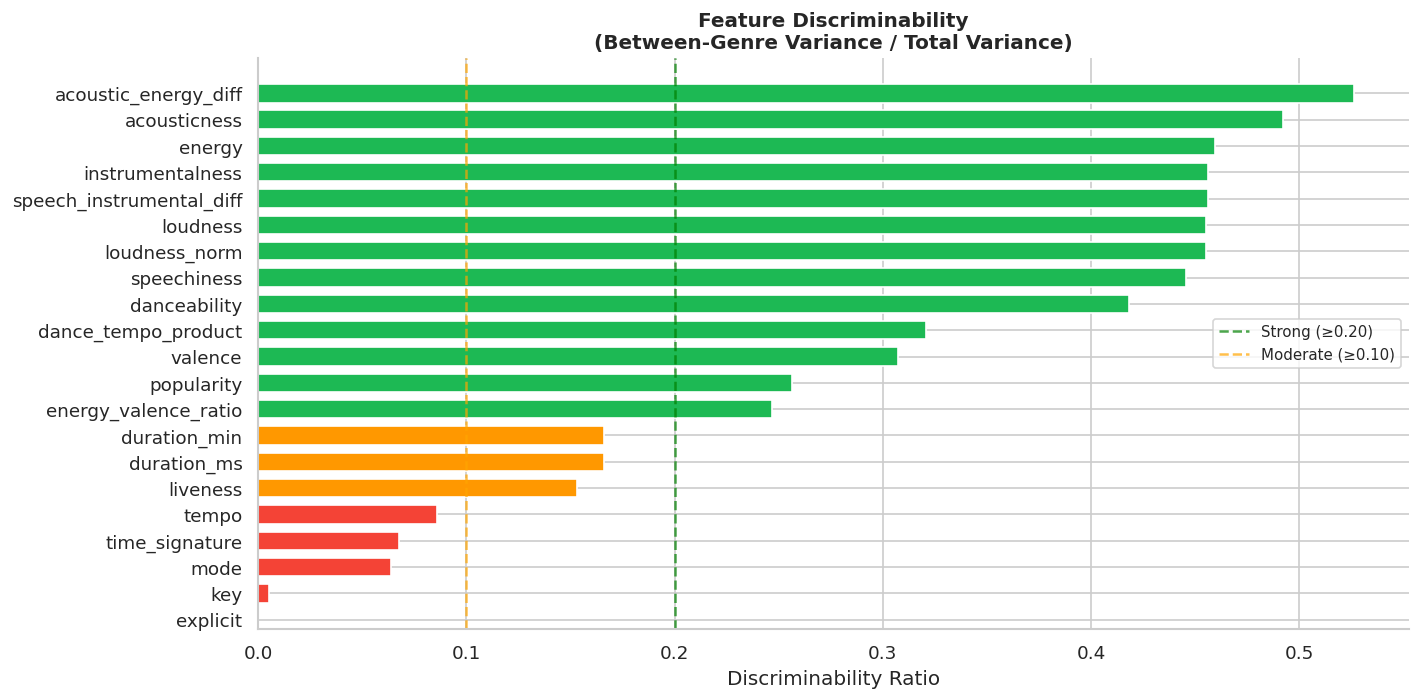

Top 10 most discriminative features:
acoustic_energy_diff        0.5264
acousticness                0.4922
energy                      0.4594
instrumentalness            0.4565
speech_instrumental_diff    0.4564
loudness                    0.4551
loudness_norm               0.4551
speechiness                 0.4456
danceability                0.4184
dance_tempo_product         0.3208


In [54]:
#Define feature columns
FEATURE_COLS = [c for c in df_clean.columns if c != 'track_genre']

#Between-genre variance / total variance
#High ratio → feature varies a lot between genres relative to within-genre noise
between_var = df_clean.groupby('track_genre')[FEATURE_COLS].mean().var()
total_var   = df_clean[FEATURE_COLS].var()
discriminability = (between_var / total_var).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
colors_d = ['#1DB954' if v >= 0.20 else '#FF9800' if v >= 0.10 else '#F44336'
            for v in discriminability.values]
ax.barh(discriminability.index[::-1], discriminability.values[::-1],
        color=colors_d[::-1], edgecolor='white', height=0.7)
ax.set_title("Feature Discriminability\n(Between-Genre Variance / Total Variance)",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Discriminability Ratio")
ax.axvline(0.20, color='green', linestyle='--', alpha=0.7, label='Strong (≥0.20)')
ax.axvline(0.10, color='orange', linestyle='--', alpha=0.7, label='Moderate (≥0.10)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig_feature_discriminability.png', dpi=120, bbox_inches='tight')
plt.show()

print("Top 10 most discriminative features:")
print(discriminability.head(10).round(4).to_string())


This chart answers the question "which features actually do the work of separating genres from each other?" by calculating for each feature how much of its variation occurs between genres versus just random noise within a genre — the higher the ratio, the more useful that feature is for classification.

### 5.6 Tempo vs Energy — Genre Scatterplot

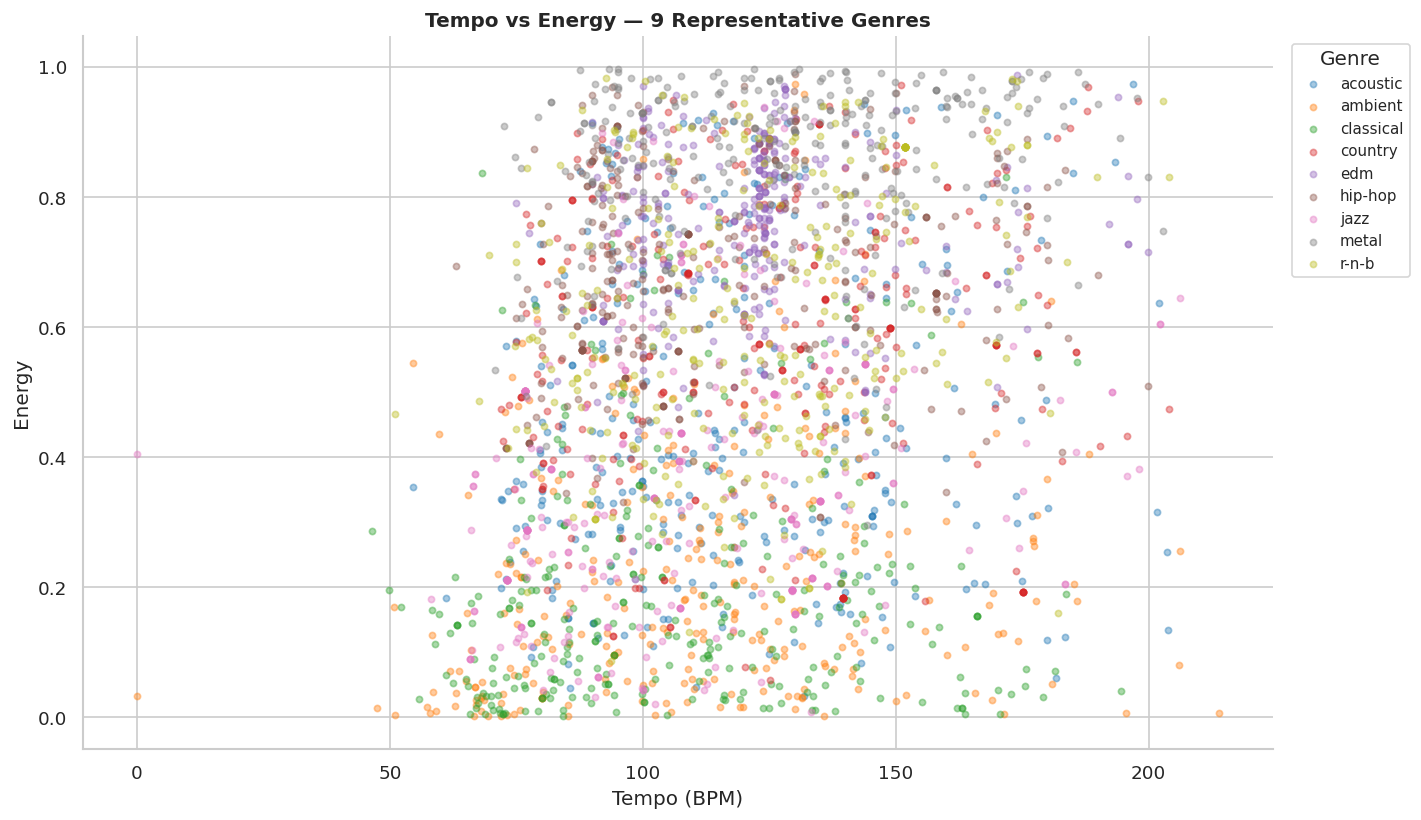

In [55]:
SCATTER_GENRES = ['classical', 'hip-hop', 'metal', 'ambient', 'edm',
                  'acoustic', 'jazz', 'r-n-b', 'country']

df_scatter = (df_clean[df_clean['track_genre'].isin(SCATTER_GENRES)]
              .groupby('track_genre', group_keys=False)
              .apply(lambda g: g.sample(min(300, len(g)), random_state=42)))

fig, ax = plt.subplots(figsize=(12, 7))
palette_sc = sns.color_palette("tab10", n_colors=len(SCATTER_GENRES))
for i, genre in enumerate(sorted(SCATTER_GENRES)):
    mask = df_scatter['track_genre'] == genre
    ax.scatter(df_scatter.loc[mask, 'tempo'],
               df_scatter.loc[mask, 'energy'],
               label=genre, alpha=0.4, s=14, color=palette_sc[i])

ax.set_title("Tempo vs Energy — 9 Representative Genres", fontsize=12, fontweight='bold')
ax.set_xlabel("Tempo (BPM)")
ax.set_ylabel("Energy")
ax.legend(title='Genre', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('fig_tempo_energy_scatter.png', dpi=120, bbox_inches='tight')
plt.show()


This plot may look messy but you can see some grouping like
* EDM groups tightly in the high tempo/high energy corner
* Classical spreads low on energy across a wide tempo range
* Hip-Hop and R&B overlap in the moderate tempo/moderate-high energy zone

This deemonstrates that even just two features together can begin to pull certain genres apart in feature space.

## 6. Prepare Data for Modeling

### Sampling Strategy — Managing 114 Classes at Scale

With 114 genres × 1,000 tracks = 114,000 rows, computation will be expensive. Rather than throwing out data randomly, I use exactly 300 songs from each of the genres to **build a leaner 34,200-row working set** that still represents every genre equally.

Because the same song can appear under multiple genre labels in this dataset, a random split could put the same song in both training and testing under different genre names — essentially letting the model "cheat" by recognizing a song it already saw. The split is designed to prevent that by treating each unique song as belonging to one side of the split only.

In [56]:
#Stratified sample: 300 tracks per genre
np.random.seed(42)
df_model = (df_clean
            .groupby('track_genre', group_keys=False)
            .apply(lambda g: g.sample(min(300, len(g)), random_state=42))
            .reset_index(drop=True))

print(f"Modelling subset shape: {df_model.shape}")
print(f"Genres represented: {df_model['track_genre'].nunique()}")
print(f"Min/Max per genre: {df_model['track_genre'].value_counts().min()} / "
      f"{df_model['track_genre'].value_counts().max()}")


Modelling subset shape: (34200, 22)
Genres represented: 114
Min/Max per genre: 300 / 300


This creates a trimmed-down modeling dataset by going genre by genre and randomly grabbing 300 tracks from each one, then stacking them all together into a single dataframe of 34,200 rows

In [57]:
#Define feature columns (all except target)
FEATURE_COLS = [c for c in df_clean.columns if c != 'track_genre']

#Encode target labels
le = LabelEncoder()
y = le.fit_transform(df_model['track_genre'])
X = df_model[FEATURE_COLS].fillna(0)

print("Label encoding: 114 genres → integers 0–113")
print("Example mappings:")
for i in range(5):
    print(f"  {i} → {le.classes_[i]}")
print("  ...")


Label encoding: 114 genres → integers 0–113
Example mappings:
  0 → acoustic
  1 → afrobeat
  2 → alt-rock
  3 → alternative
  4 → ambient
  ...


Above the LabelEncoder converts each genre name into a number from 0 to 113

In [59]:
#Stratified train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")
print(f"Features: {X_train.shape[1]}")

#Scale features (critical for KNN distance)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("\nStandardScaler applied — zero mean, unit variance.")
print(f"Train mean check (should be ≈0): {X_train_sc.mean():.4f}")
print(f"Train std check  (should be ≈1): {X_train_sc.std():.4f}")


Train: 27,360 rows | Test: 6,840 rows
Features: 21

StandardScaler applied — zero mean, unit variance.
Train mean check (should be ≈0): -0.0000
Train std check  (should be ≈1): 0.9759


Above, to prepare the data for KNN:

1) Split the 34,200 rows into 80% for training and 20% for testing
2) Scaling squishes every feature onto the same 0-centered range first, so that tempo, danceability, and duration_ms all get an equal vote when the model is deciding which songs are closest to each other.

## 7. Baseline Model — K-Nearest Neighbors (KNN)

### Rationale
KNN directly mirrors the intuition behind genre classification: assign a new
track to the genre of its closest audio neighbours in feature space. This
mirrors how humans — and recommender systems — mentally group similar-sounding
music.


### 7.1 Hyperparameter Tuning — Finding Optimal K


In [60]:
#Cross-validate K from 1 to 20
#Range limited to 20 for computational efficiency on 114-class problem.
#Each CV fold trains and predicts 114-way classification.

k_range = range(1, 21)
cv_scores_mean = []
cv_scores_std  = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Cross-validating KNN (K=1 to 20)...")
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean', n_jobs=-1)
    scores = cross_val_score(knn, X_train_sc, y_train, cv=cv, scoring='accuracy')
    cv_scores_mean.append(scores.mean())
    cv_scores_std.append(scores.std())
    print(f"  K={k:2d}  CV Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

best_k = list(k_range)[np.argmax(cv_scores_mean)]
print(f"\n✓ Best K: {best_k}  |  CV Accuracy: {max(cv_scores_mean):.4f}")


Cross-validating KNN (K=1 to 20)...
  K= 1  CV Accuracy: 0.1694 ± 0.0042
  K= 2  CV Accuracy: 0.1537 ± 0.0033
  K= 3  CV Accuracy: 0.1546 ± 0.0032
  K= 4  CV Accuracy: 0.1588 ± 0.0029
  K= 5  CV Accuracy: 0.1669 ± 0.0052
  K= 6  CV Accuracy: 0.1710 ± 0.0037
  K= 7  CV Accuracy: 0.1740 ± 0.0020
  K= 8  CV Accuracy: 0.1769 ± 0.0027
  K= 9  CV Accuracy: 0.1788 ± 0.0033
  K=10  CV Accuracy: 0.1798 ± 0.0015
  K=11  CV Accuracy: 0.1798 ± 0.0011
  K=12  CV Accuracy: 0.1810 ± 0.0022
  K=13  CV Accuracy: 0.1817 ± 0.0012
  K=14  CV Accuracy: 0.1819 ± 0.0021
  K=15  CV Accuracy: 0.1825 ± 0.0016
  K=16  CV Accuracy: 0.1821 ± 0.0023
  K=17  CV Accuracy: 0.1834 ± 0.0023
  K=18  CV Accuracy: 0.1845 ± 0.0021
  K=19  CV Accuracy: 0.1840 ± 0.0016
  K=20  CV Accuracy: 0.1834 ± 0.0022

✓ Best K: 18  |  CV Accuracy: 0.1845


In order to figure out how many neighbors the model should consult before making a decision, test every value of K from 1 to 20, and for each one run 5-fold cross-validation.

* split the training data into 5 chunks
* train on 4 of them
* test on the 5th
* rotate through all 5 combinations
* averagesthe result

**K=18 is best.**



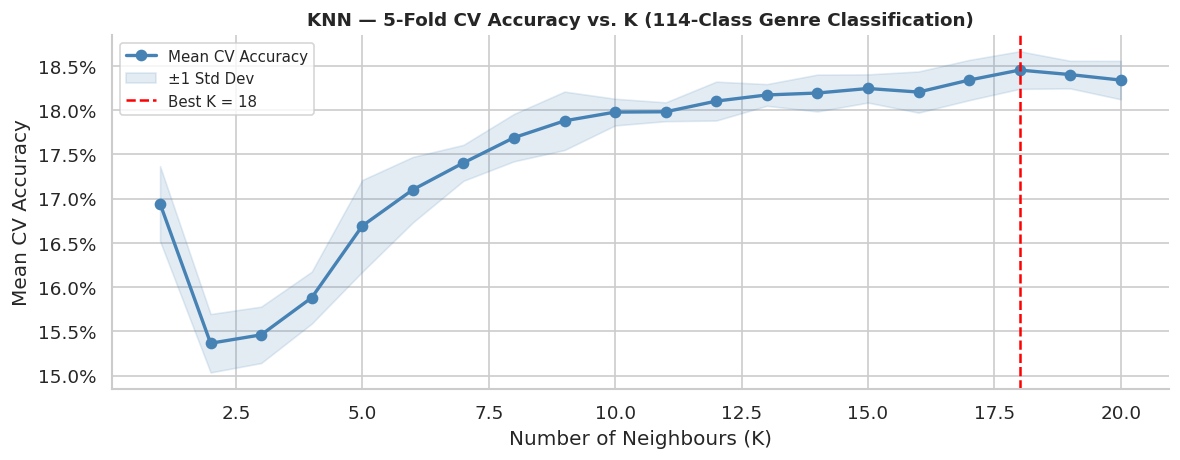

In [61]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(list(k_range), cv_scores_mean, 'o-', color='steelblue', linewidth=2, markersize=6, label='Mean CV Accuracy')
ax.fill_between(list(k_range),
                np.array(cv_scores_mean) - np.array(cv_scores_std),
                np.array(cv_scores_mean) + np.array(cv_scores_std),
                alpha=0.15, color='steelblue', label='±1 Std Dev')
ax.axvline(best_k, color='red', linestyle='--', linewidth=1.5, label=f'Best K = {best_k}')
ax.set_title("KNN — 5-Fold CV Accuracy vs. K (114-Class Genre Classification)",
             fontsize=11, fontweight='bold')
ax.set_xlabel("Number of Neighbours (K)")
ax.set_ylabel("Mean CV Accuracy")
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals=1))
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig_knn_k_selection.png', dpi=120, bbox_inches='tight')
plt.show()


Here we see the "shape" of the K selection decision.

### 7.2 Final Model Training & Test-Set Evaluation

In [62]:
#Train on full training set with best K
knn_final = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean', n_jobs=-1)
knn_final.fit(X_train_sc, y_train)

y_pred = knn_final.predict(X_test_sc)
test_acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')

print(f"=== KNN Baseline Results (K={best_k}, 114-Class) ===")
print(f"Test Accuracy  : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"Macro F1 Score : {macro_f1:.4f}")
print(f"Random Chance  : {1/114:.4f}  ({1/114*100:.2f}%)")
print(f"Lift over random: {test_acc / (1/114):.1f}×")
print()
print("=== Per-Genre Classification Report (first 30 genres) ===")
report_dict = classification_report(y_test, y_pred,
                                    target_names=le.classes_,
                                    output_dict=True)
report_df = pd.DataFrame(report_dict).T
print(report_df.iloc[:30].round(3).to_string())


=== KNN Baseline Results (K=18, 114-Class) ===
Test Accuracy  : 0.1883  (18.83%)
Macro F1 Score : 0.1779
Random Chance  : 0.0088  (0.88%)
Lift over random: 21.5×

=== Per-Genre Classification Report (first 30 genres) ===
                precision  recall  f1-score  support
acoustic            0.045   0.083     0.058     60.0
afrobeat            0.071   0.100     0.083     60.0
alt-rock            0.039   0.050     0.044     60.0
alternative         0.040   0.033     0.036     60.0
ambient             0.262   0.350     0.300     60.0
anime               0.062   0.067     0.065     60.0
black-metal         0.196   0.317     0.242     60.0
bluegrass           0.226   0.433     0.297     60.0
blues               0.022   0.017     0.019     60.0
brazil              0.133   0.133     0.133     60.0
breakbeat           0.173   0.150     0.161     60.0
british             0.000   0.000     0.000     60.0
cantopop            0.142   0.267     0.185     60.0
chicago-house       0.232   0.383    

Above, The best K from cross-validation is used to train the final model.
A per-genre breakdown allows me to see which genres the model handles confidently and which ones it struggles with.

### 7.3 Per-Genre F1 Score Distribution

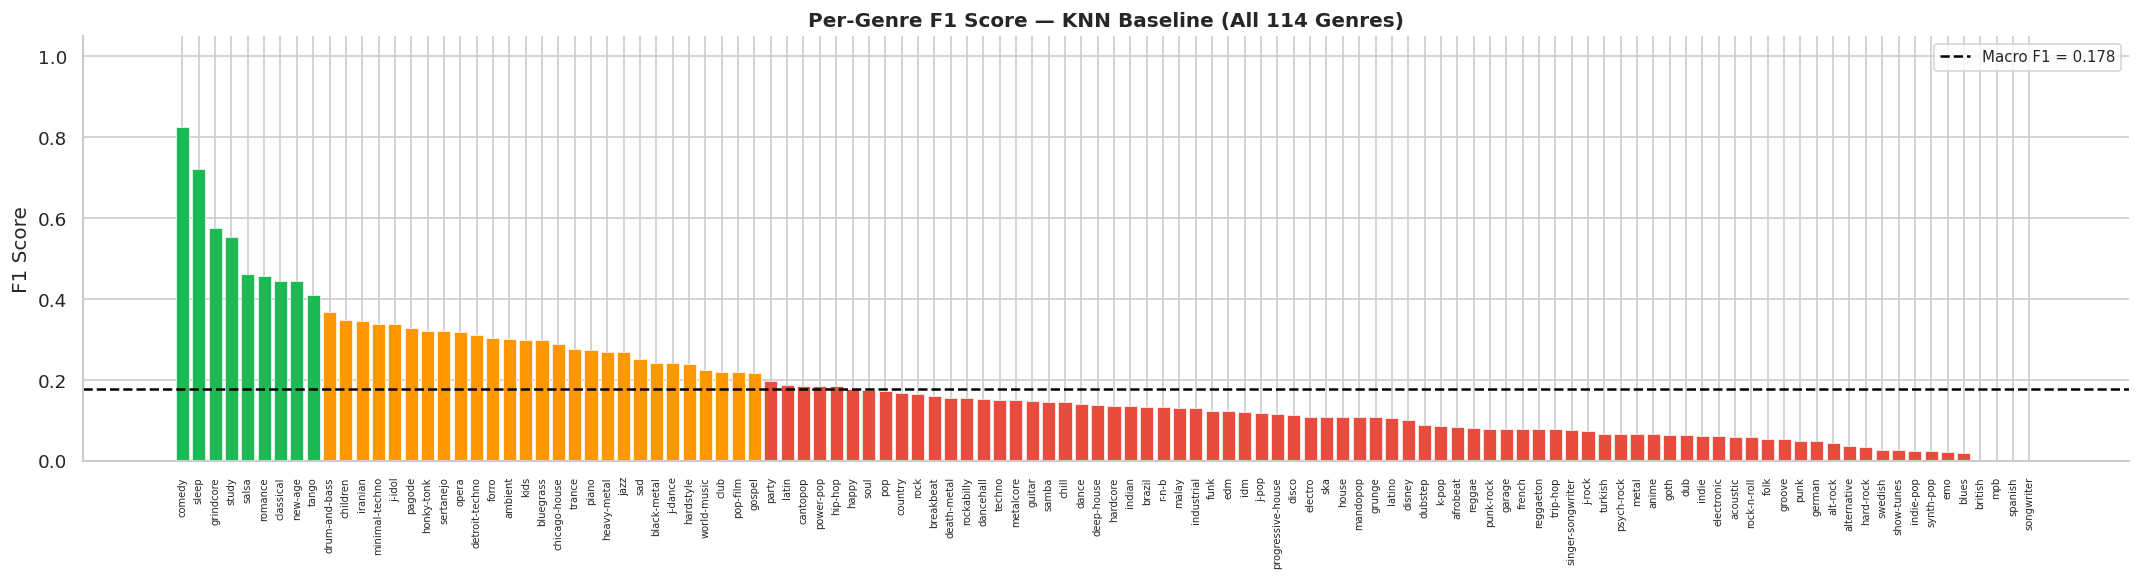

Genres with F1 ≥ 0.40: 9
Genres with F1 < 0.20: 78

Top 5 best-classified genres:
comedy            0.826
sleep             0.722
grindcore         0.575
study             0.554
salsa             0.462
romance           0.458
classical         0.444
new-age           0.444
tango             0.410
drum-and-bass     0.368
children          0.348
iranian           0.344
minimal-techno    0.338
j-idol            0.338
pagode            0.327
honky-tonk        0.320
sertanejo         0.319
opera             0.317
detroit-techno    0.310
forro             0.303

Top 5 hardest genres:
electronic     0.061
acoustic       0.058
rock-n-roll    0.058
folk           0.054
groove         0.054
punk           0.048
german         0.048
alt-rock       0.044
alternative    0.036
hard-rock      0.034
swedish        0.027
show-tunes     0.026
indie-pop      0.023
synth-pop      0.023
emo            0.022
blues          0.019
british        0.000
mpb            0.000
spanish        0.000
songwriter     0

In [42]:
#Per-genre F1 scores
per_genre_f1 = pd.Series(
    {le.classes_[i]: report_dict[le.classes_[i]]['f1-score']
     for i in range(len(le.classes_))
     if le.classes_[i] in report_dict},
    name='f1'
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(18, 5))
color_map = ['#1DB954' if v >= 0.40 else '#FF9800' if v >= 0.20 else '#E74C3C'
             for v in per_genre_f1.values]
ax.bar(per_genre_f1.index, per_genre_f1.values, color=color_map, edgecolor='white', linewidth=0.4)
ax.axhline(macro_f1, color='black', linestyle='--', linewidth=1.5,
           label=f'Macro F1 = {macro_f1:.3f}')
ax.set_title("Per-Genre F1 Score — KNN Baseline (All 114 Genres)",
             fontsize=12, fontweight='bold')
ax.set_ylabel("F1 Score")
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=90, labelsize=6)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig_per_genre_f1.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Genres with F1 ≥ 0.40: {(per_genre_f1 >= 0.40).sum()}")
print(f"Genres with F1 < 0.20: {(per_genre_f1 < 0.20).sum()}")
print(f"\nTop 5 best-classified genres:")
print(per_genre_f1.head(20).round(3).to_string())
print(f"\nTop 5 hardest genres:")
print(per_genre_f1.tail(20).round(3).to_string())


Above we can see the **TOP 20 genres** the model does best, and struggles with.

## 8. Summary of Findings & Next Steps

---

### EDA Key Takeaways

- **Perfectly balanced dataset** — 1,000 tracks per genre means no class weighting is needed and accuracy is a fair metric to use
- **Top discriminative features** — `acousticness`, `energy`, `instrumentalness`, `speechiness`, and `loudness_norm` do the most work separating genres
- **Classical stands apart** — extremely high acousticness and instrumentalness give it the highest discriminability score and the cleanest separation in feature space
- **Metal / Heavy-Metal / Black-Metal overlap** — nearly identical energy and loudness profiles make this the hardest cluster to pull apart
- **Hip-hop / R&B overlap** — both share high speechiness and danceability; the boundary between them is cultural rather than acoustic
- **Ambient / Sleep / Study overlap** — near-identical feature vectors across these genres; purpose-built background music actively resists separation
- **Popularity & explicit content** — both rank low on discriminability and neither is a reliable standalone genre signal
- **Same track in multiple genres** — 16,299 track IDs appear under 2 or more genre labels, reflecting the real-world multi-label nature of music

---

### Baseline KNN Model Performance


The KNN baseline was trained on 20 features — 14 original Spotify audio descriptors plus 6 engineered composites — and tuned via 5-fold cross-validation to find the optimal number of neighbors. Once trained, it was evaluated against a held-out test set spanning all 114 genres, with performance measured using both accuracy and macro F1 to ensure every genre is weighted equally regardless of size.


---

### Next Steps — Module 24

**TBD**
